> 📓 **Lesson 1.10 — Part 3 of 4: Seaborn for Statistical Graphics**
>
> This notebook was split out of the original single `data_visualization_lesson.ipynb` so each part can be opened and run on its own. If you are starting here rather than at Part 1, run the **Setup** cell below first — it loads the same data used throughout Lesson 1.10.
>
> Other notebooks in this set: `Part_1_three_pillars.ipynb`, `Part_2_matplotlib_fundamentals.ipynb`, `Part_4_chart_choice.ipynb`

# Lesson 1.10: Data Visualisation & Storytelling

Lesson 1.8 asked *can I trust this data?* Lesson 1.9 asked *what is the pattern?* You answered both.
You have a table that shows exactly what is happening to the café chain.

This lesson is about the last twenty seconds — the part where the owner either acts on it or doesn't.

**Structure — the four learning outcomes, in order:**
* **Part 1: The Three Pillars** — *apply* perception, design and storytelling to fix a bad chart.
* **Part 2: Matplotlib Fundamentals** — *create* charts with the Figure → Axes → plot hierarchy.
* **Part 3: Seaborn for Statistical Graphics** — *use* the right statistical view for the data type.
* **Part 4: Chart Choice & the One Slide** — *select* the chart your message needs, and build it.

**How to work through this:** read the `# 👉` comment above each line before you run the cell. Charts are the one
topic where you learn most by breaking things on purpose, so several cells here are deliberately bad.


> **🧭 Today's flow — 180 minutes.** One message, four learning outcomes, in order:
>
> | | Section | Learning outcome | Time |
> |---|---|---|---|
> | — | Setup + why this matters | | 5 min |
> | **Part 1** | The Three Pillars | **Apply** perception, design, storytelling | 40 min |
> | ☕ | *Break* | | 10 min |
> | **Part 2** | Matplotlib Fundamentals | **Create** charts: Figure → Axes → plot | 45 min |
> | ☕ | *Break* | | 10 min |
> | **Part 3** | Seaborn | **Use** statistical graphics for the data type | 45 min |
> | **Part 4** | Chart Choice & the One Slide | **Select** the chart the message needs | 25 min |
>
> **The spine:** the same business problem as 1.9 — *The Daily Grind* café chain — and the same
> files. You already know the answer. Today you make it land.
>
> Each of Parts 1–3 ends with a **🛠️ Group Exercise**. Deep dives (colour theory, accessibility,
> Gestalt, the research behind pre-attentive processing) live in `reference.md`.


### The one rule this lesson is built on

> **The chart is chosen by the message, not by taste.**

Write the sentence you want the audience to leave with, in words, first. The chart type follows from
that sentence almost mechanically. Every mistake in Part 1 comes from doing it the other way round —
picking a chart, then hunting for something to say.


### Setup


In [14]:
# 👉 pandas for the data, matplotlib for drawing, seaborn for statistical charts.
#    `plt` and `sns` are the conventional nicknames -- you will see them in every tutorial.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 👉 Housekeeping only: keep version-deprecation notices out of our output.
import warnings
warnings.filterwarnings("ignore")

# 👉 Draw charts underneath the cell that made them, inside the notebook.
%matplotlib inline


In [15]:
# 👉 The same café data as Lesson 1.9, plus the decision table you produced at the end of it.
sales = pd.read_csv("../data/daily_sales.csv", parse_dates=["date"])
outlets = pd.read_csv("../data/outlets.csv", parse_dates=["opened_date"])
tickets = pd.read_csv("../data/tickets_week.csv", parse_dates=["txn_datetime"])
decision = pd.read_csv("../data/lesson19_decision.csv", index_col="outlet_id")

decision.round(1)


,outlet_name,rev_2025_h1,change_pct,rent_pct_of_revenue,rev_per_staff_hour
outlet_id,,,,,
OUT-03,Marina Bay,203147.5,-27.9,28.4,19.9
OUT-01,Raffles Place,309339.2,-1.5,15.9,26.4
OUT-02,Tampines Mall,279272.0,1.3,14.6,25.5
OUT-04,Holland Village,253450.1,26.5,14.7,26.7
OUT-05,NaN,61309.5,NaN,NaN,26.0


In [16]:
# 👉 Two summaries we will chart all session. Both are straight out of Lesson 1.9.
#    (1) monthly revenue per outlet -- one column per outlet, dates on the index.
monthly = sales.pivot_table(
    index="date", columns="outlet_id", values="revenue_sgd", aggfunc="sum"
).resample("M").sum()

# 👉 (2) revenue by outlet and daypart.
by_daypart = sales.pivot_table(
    index="outlet_id", columns="daypart", values="revenue_sgd", aggfunc="sum"
)[["Morning", "Midday", "Evening"]]

# 👉 Friendly names, for chart labels. Codes belong in databases, not on slides.
names = outlets.set_index("outlet_id")["outlet_name"].to_dict()

monthly.tail(5).round(0)

# by_daypart.round(0)


outlet_id,OUT-01,OUT-02,OUT-03,OUT-04,OUT-05
date,,,,,
2025-02-28,47764.0,42186.0,32165.0,38456.0,0.0
2025-03-31,50549.0,48397.0,34927.0,45970.0,20493.0
2025-04-30,53250.0,47146.0,33777.0,41892.0,19595.0
2025-05-31,52570.0,50158.0,33822.0,44123.0,21221.0
2025-06-30,53255.0,44896.0,32818.0,44700.0,0.0


### 🎬 Why this matters — the same finding, three ways

**The situation.** You have five minutes at the end of a Monday meeting. The owner is deciding
whether to renew the Marina Bay lease. You already know the answer: chain revenue is flat because
Marina Bay is falling and Holland Village is rising, and Marina Bay's fall is a step dated to the
first week of November 2024.

Below is that finding presented three ways. Same data. Same truth. Run all three, then decide which
one makes somebody *do* something.


In [17]:
# 👉 Version 1: the numbers. Complete, precise, and almost impossible to read at speed.
monthly.round(0).tail(12)


outlet_id,OUT-01,OUT-02,OUT-03,OUT-04,OUT-05
date,,,,,
2024-07-31,55315.0,48409.0,48581.0,36779.0,0.0
2024-08-31,52530.0,48299.0,47079.0,38089.0,0.0
2024-09-30,50083.0,45214.0,43679.0,36634.0,0.0
2024-10-31,54212.0,44320.0,46138.0,37368.0,0.0
2024-11-30,48362.0,45761.0,35344.0,37488.0,0.0
2024-12-31,51839.0,46734.0,33956.0,39548.0,0.0
2025-01-31,51951.0,46489.0,35638.0,38309.0,0.0
2025-02-28,47764.0,42186.0,32165.0,38456.0,0.0
2025-03-31,50549.0,48397.0,34927.0,45970.0,20493.0


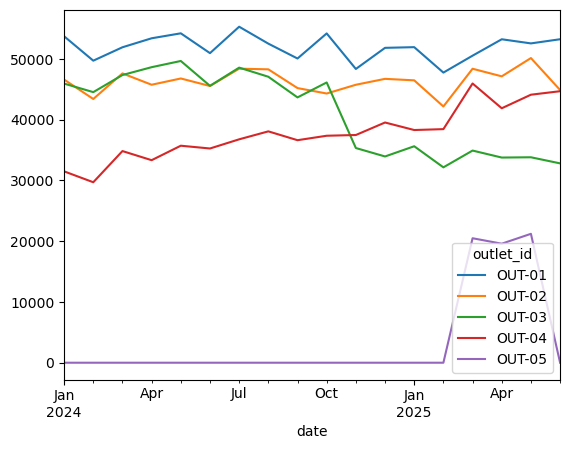

In [18]:
# 👉 Version 2: a chart, made without thinking. Every default left as it came.
monthly.plot()
plt.show()


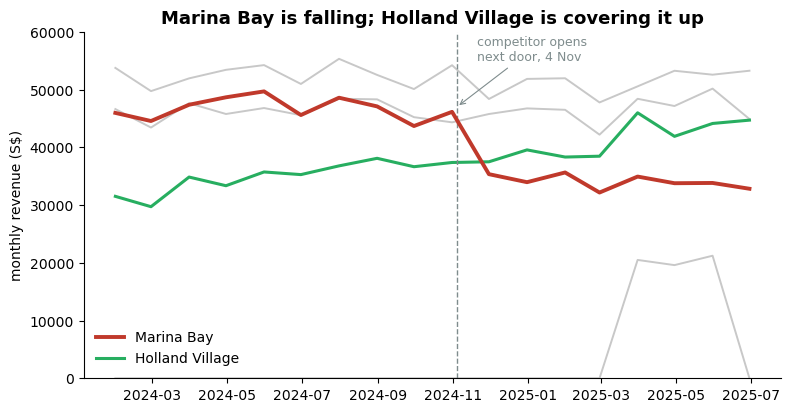

In [19]:
# 👉 Version 3: the same numbers, drawn to make one point. Read the code later --
#    for now just compare what your eye does with this versus the two above.
# color codes: https://htmlcolorcodes.com/color-names/

fig, ax = plt.subplots(figsize=(9, 4.5))

for col in monthly.columns:
    if col == "OUT-03":
        ax.plot(monthly.index, monthly[col], color="#c0392b", linewidth=2.8, label="Marina Bay", zorder=3) # zorder controls which lines are drawn on top of which others, 3 is the highest here
    elif col == "OUT-04":
        ax.plot(monthly.index, monthly[col], color="#27ae60", linewidth=2.2, label="Holland Village", zorder=2)
    else:
        ax.plot(monthly.index, monthly[col], color="#c8c8c8", linewidth=1.4, zorder=1)

ax.axvline(pd.Timestamp("2024-11-04"), color="#7f8c8d", linestyle="--", linewidth=1)
ax.annotate("competitor opens\nnext door, 4 Nov",
            xy=(pd.Timestamp("2024-11-04"), 47000), xytext=(pd.Timestamp("2024-11-20"), 55000),
            fontsize=9, color="#7f8c8d",
            arrowprops=dict(arrowstyle="->", color="#7f8c8d", linewidth=0.8))

ax.set_title("Marina Bay is falling; Holland Village is covering it up", fontsize=13, weight="bold")
ax.set_ylabel("monthly revenue (S$)")
ax.set_ylim(0, 60000)
ax.legend(frameon=False, loc="lower left") # remove the box around the legend
ax.spines[["top", "right"]].set_visible(False) # remove the top and right borders
plt.show()


**What changed between versions 2 and 3?** Nothing about the data. Four things about the drawing:

1. **One sentence as the title.** Not "Monthly Revenue" — the actual finding, in words.
2. **Colour used as an argument.** Two lines carry the point; the other three went grey. Your eye
   found the red line before you consciously read anything. That reflex is *pre-attentive processing*,
   and it fires in 200 to 500 milliseconds. Charts either use it or waste it.
3. **The cause annotated on the chart.** The reader does not have to be told separately.
4. **Clutter removed.** Two spines gone, no box round the legend, no chart junk competing for attention.

That is the whole lesson: **perception** (how eyes work), **design** (honest, uncluttered choices),
**storytelling** (one message, stated). Everything else is syntax.


## Part 3: Seaborn for Statistical Graphics

**Learning outcome 3:** *Use Seaborn to produce statistical graphics appropriate for different data
types and questions.*

**Goal:** seaborn is matplotlib with statistics built in. It takes a DataFrame and column *names*,
does the grouping itself, and returns a matplotlib Axes you can still customise.

⏱️ ~45 min including Group Exercise 3


In [55]:
# 👉 `set_theme` sets fonts, colours and grid for everything after it. One line, whole notebook.
sns.set_theme(style="whitegrid", palette="colorblind")

# 👉 One row per till receipt, for the week of 16-22 June 2025. Averages hid this file until now.
print(tickets.shape)
tickets.head(3)


(4916, 8)


,txn_id,txn_datetime,outlet_id,daypart,category,items,amount_sgd,payment_method
0,T502810,2025-06-16 07:00:00,OUT-03,Morning,Pastry,1,4.84,PayNow
1,T502747,2025-06-16 07:00:00,OUT-03,Morning,Coffee,1,5.71,Card
2,T501542,2025-06-16 07:01:00,OUT-02,Morning,Coffee,1,6.81,PayNow


### 3.1: Distributions — what an average hides

Every outlet's average ticket sits between \$7.90 and \$8.80. That number is true and nearly useless:
it cannot tell you whether everyone spends about \$8, or whether most people spend \$6 and a minority
spend \$15.


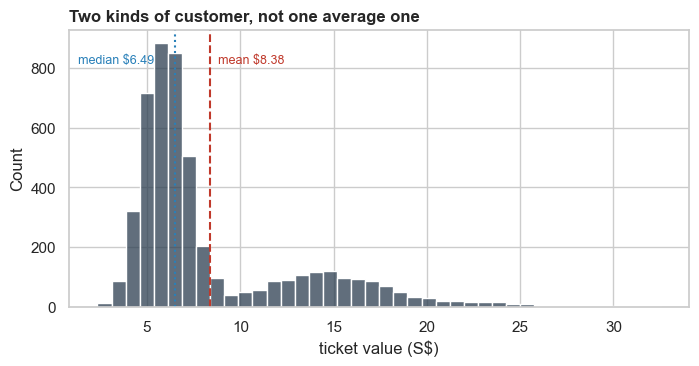

In [36]:
# 👉 `histplot` buckets the values and counts each bucket. `bins=40` = 40 buckets.
fig, ax = plt.subplots(figsize=(8, 3.6))

sns.histplot(data=tickets, x="amount_sgd", bins=40, color="#2c3e50", ax=ax)

# 👉 Mark the two summary numbers everyone reports, so you can see where they land.
mean_v, median_v = tickets["amount_sgd"].mean(), tickets["amount_sgd"].median()

ax.axvline(mean_v, color="#c0392b", linestyle="--", linewidth=1.5)
ax.text(mean_v + 0.4, ax.get_ylim()[1] * 0.88, f"mean ${mean_v:.2f}", color="#c0392b", fontsize=9)

ax.axvline(median_v, color="#2980b9", linestyle=":", linewidth=1.5)
ax.text(median_v - 5.2, ax.get_ylim()[1] * 0.88, f"median ${median_v:.2f}", color="#2980b9", fontsize=9)

ax.set_title("Two kinds of customer, not one average one", loc="left", weight="bold")
ax.set_xlabel("ticket value (S$)")
plt.show()


> **Read the shape.** There is a tall spike of small tickets around \$5–7 (a coffee, a pastry) and a
> long, flatter second hump around \$13–18 (a meal). The mean lands in the **dip between them** — a value
> that describes hardly any real customer. The median (\$6.49) is not much better on its own; it just
> sits inside the first hump and ignores the second.
>
> This is why "the average ticket is \$8.38" is a dangerous sentence. A promotion designed for an
> \$8 customer is aimed at somebody who does not exist. There are two businesses in this café —
> drinks and meals — and any decision has to pick one, or address both deliberately.


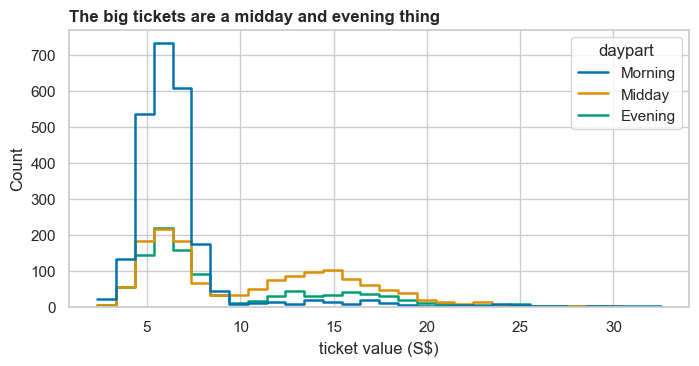

In [37]:
# 👉 `hue=` splits one chart by a category. `element="step"` keeps overlapping shapes readable.
fig, ax = plt.subplots(figsize=(8, 3.6))

sns.histplot(data=tickets, x="amount_sgd", hue="daypart", bins=30,
             element="step", fill=False, linewidth=1.8, ax=ax)

ax.set_title("The big tickets are a midday and evening thing", loc="left", weight="bold")
ax.set_xlabel("ticket value (S$)")
plt.show()


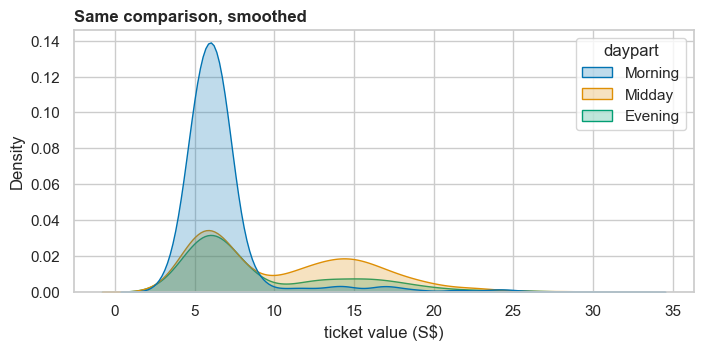

In [38]:
# 👉 A KDE is a smoothed version of a histogram -- no bin edges, so no bin-width arguments.
#    Good for comparing shapes; bad when you need exact counts.
fig, ax = plt.subplots(figsize=(8, 3.4))

sns.kdeplot(data=tickets, x="amount_sgd", hue="daypart", fill=True, alpha=0.25, ax=ax)

ax.set_title("Same comparison, smoothed", loc="left", weight="bold")
ax.set_xlabel("ticket value (S$)")
plt.show()


### 3.2: Categorical comparisons — box plots and bars

A box plot compresses a distribution into five numbers: minimum, lower quartile, **median**, upper
quartile, maximum, with outliers as dots. It is the right chart when you have several groups and need
to compare their *spread*, not just their centre.


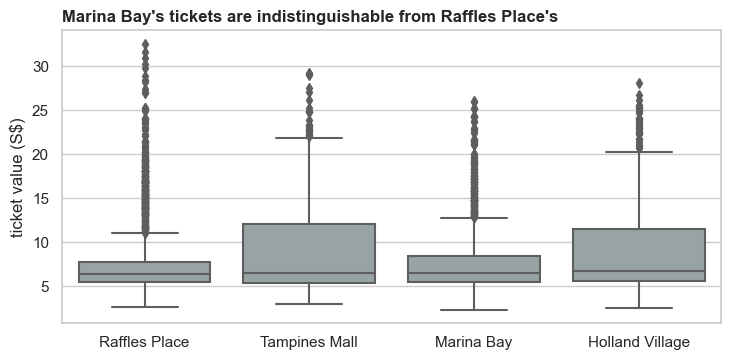

In [39]:
# 👉 One box per outlet. `order=` fixes the sequence, so it is a choice and not an accident.
fig, ax = plt.subplots(figsize=(8.5, 3.8))
# Box plots show the median, quartiles, and outliers. The box is the middle 50% of the data; the whiskers are 1.5× the interquartile range; dots beyond that are outliers.

order = ["OUT-01", "OUT-02", "OUT-03", "OUT-04"]
sns.boxplot(data=tickets[tickets["outlet_id"].isin(order)],
            x="outlet_id", y="amount_sgd", order=order, color="#95a5a6", ax=ax)

ax.set_xticklabels([names[o] for o in order])
ax.set_title("Marina Bay's tickets are indistinguishable from Raffles Place's",
             loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("ticket value (S$)")
plt.show()


> **A finding can be an absence.** All four medians sit near \$6.40. Marina Bay's box is
> indistinguishable from Raffles Place's — its nearest twin, another CBD commuter café — which rules
> out an entire theory: Marina Bay's problem is *not* that its customers spend less per visit. They
> spend the same; there are simply fewer of them. One chart, and half the possible explanations are
> gone.
>
> **Read the other two boxes too.** Tampines Mall and Holland Village have *taller* boxes: same
> median, wider spread, because they sell more meals alongside the drinks. So the honest claim is the
> comparison that matters, not the sweeping one — "Marina Bay matches Raffles Place", not "all four
> are identical". A title is a claim, and the chart has to support the claim you put on it.


### 3.3: Violin plots and bar plots (Self-Study)

Violin plot and bar plots are the same data, different views. The violin shows the shape of the distribution; the bar shows the mean and a 95% confidence interval. Both are valid, but they answer different questions.

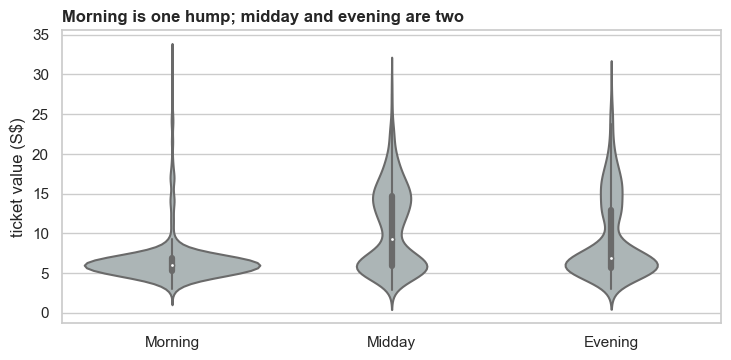

In [40]:
# 👉 A violin plot is a box plot plus the shape of the distribution -- it shows the two humps
#    that the box hides. More information, slightly more to explain to an audience.
fig, ax = plt.subplots(figsize=(8.5, 3.8))

sns.violinplot(data=tickets, x="daypart", y="amount_sgd",
               order=["Morning", "Midday", "Evening"], color="#aab7b8", ax=ax)

ax.set_title("Morning is one hump; midday and evening are two", loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("ticket value (S$)")
plt.show()


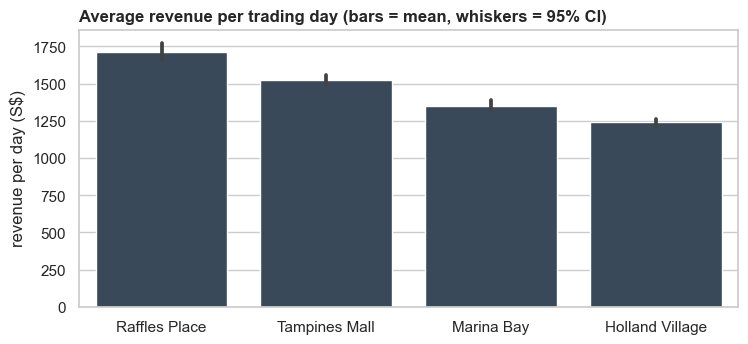

In [41]:
# 👉 `barplot` aggregates for you: by default it plots the MEAN and a 95% confidence interval (CI).
#    Know that, or you will report a mean while thinking you reported a total.
# 95% CI = mean ± 1.96 × (std / √n), where n is the number of observations in that group. More to b e explained later in module 3, but the key is that the whiskers are not the min and max.
daily_totals = sales.groupby(["date", "outlet_id"], as_index=False)["revenue_sgd"].sum()

fig, ax = plt.subplots(figsize=(8.5, 3.6))
sns.barplot(data=daily_totals[daily_totals["outlet_id"].isin(order)],
            x="outlet_id", y="revenue_sgd", order=order, errorbar=("ci", 95),
            color="#34495e", ax=ax)

ax.set_xticklabels([names[o] for o in order])
ax.set_title("Average revenue per trading day (bars = mean, whiskers = 95% CI)",
             loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("revenue per day (S$)")
plt.show()


### 3.4: Relationships — scatter and regression (Self-Study)

A scatter plot answers "do these two move together?" — the visual version of the correlation you
computed in Lesson 1.9. Always look at the scatter *before* trusting a correlation number.


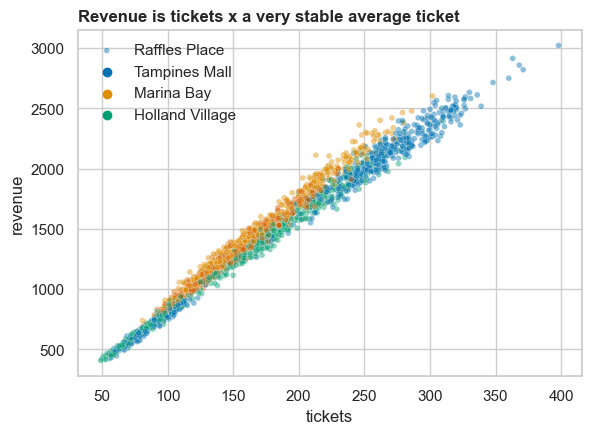

In [42]:
# 👉 One point per outlet per day: tickets sold against revenue taken.
fig, ax = plt.subplots(figsize=(6.5, 4.5))

daily = sales.groupby(["date", "outlet_id"], as_index=False).agg(
    revenue=("revenue_sgd", "sum"), tickets=("tickets", "sum")
)

sns.scatterplot(data=daily[daily["outlet_id"].isin(order)],
                x="tickets", y="revenue", hue="outlet_id", alpha=0.45, s=18, ax=ax)

ax.set_title("Revenue is tickets x a very stable average ticket", loc="left", weight="bold")
ax.legend(title="", labels=[names[o] for o in order], frameon=False)
plt.show()


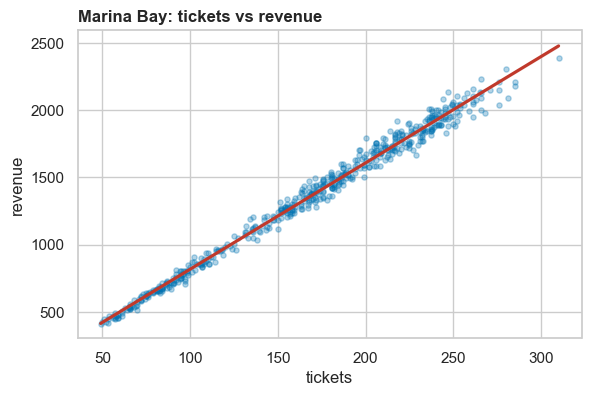

In [43]:
# 👉 `regplot` adds a fitted straight line and a shaded confidence band around it.
fig, ax = plt.subplots(figsize=(6.5, 4))

marina_daily = daily[daily["outlet_id"] == "OUT-03"]
sns.regplot(data=marina_daily, x="tickets", y="revenue",
            scatter_kws=dict(alpha=0.3, s=14), line_kws=dict(color="#c0392b"), ax=ax)

ax.set_title("Marina Bay: tickets vs revenue", loc="left", weight="bold")
plt.show()


> **Be careful what you conclude from that line.** It is nearly perfect, which sounds impressive and
> means almost nothing: revenue *is* tickets multiplied by the average ticket, so we have discovered
> arithmetic. A tight fit between two quantities that are definitionally linked is not a finding.
> Ask "could this have come out any other way?" before you put a regression line on a slide.


### 3.5: Heatmaps and small multiples (Self-Study)

A heatmap encodes value as colour on a grid. It suits exactly the shape that comes out of
`pivot_table`: two categorical axes and one number.


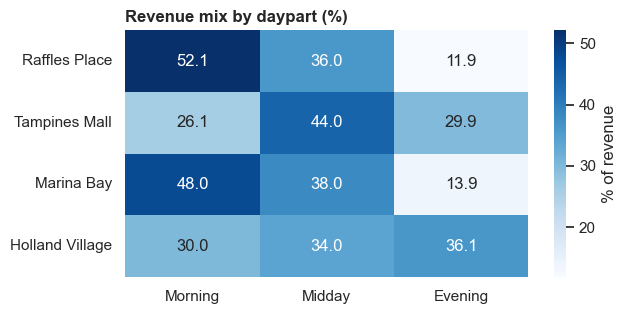

In [44]:
# 👉 The daypart mix from Part 1, as a heatmap. `annot=True` prints the numbers in the cells --
#    which is what makes a heatmap honest, because colour alone cannot be read precisely.
fig, ax = plt.subplots(figsize=(6.5, 3.2))

sns.heatmap(mix4, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% of revenue"}, ax=ax)

ax.set_title("Revenue mix by daypart (%)", loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()


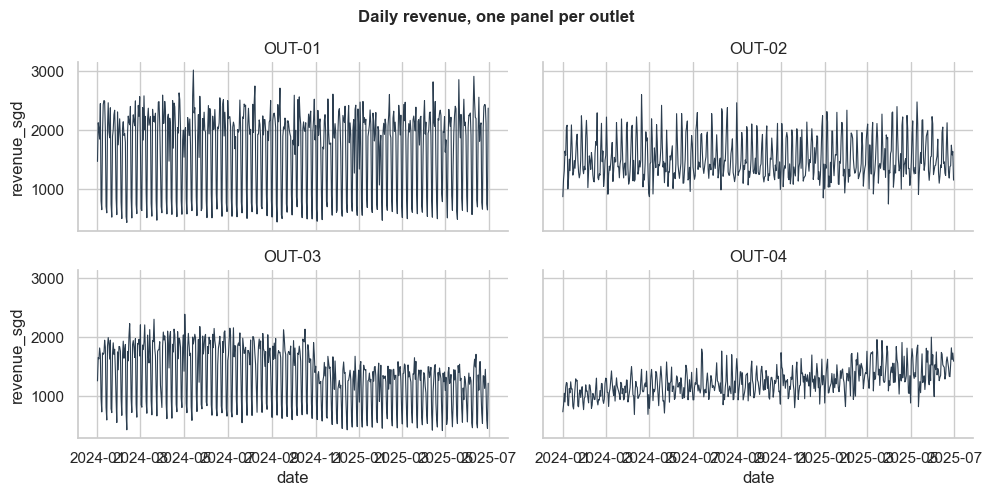

In [45]:
# 👉 `relplot` makes small multiples in one line: `col=` says which column to split panels by.
#    Note this returns a FacetGrid (a Figure-level object), not an Axes.
weekday_mean = (
    sales.groupby(["outlet_id", "date"], as_index=False)["revenue_sgd"].sum()
)
weekday_mean["weekday"] = weekday_mean["date"].dt.day_name().str[:3]

g = sns.relplot(
    data=weekday_mean[weekday_mean["outlet_id"].isin(order)],
    x="date", y="revenue_sgd", col="outlet_id", col_wrap=2,
    kind="line", height=2.4, aspect=2.1, color="#2c3e50", linewidth=0.8,
)

g.set_titles("{col_name}")
g.figure.suptitle("Daily revenue, one panel per outlet", y=1.03, fontsize=12, weight="bold")
plt.show()


> **Figure-level versus Axes-level.** `histplot`, `boxplot`, `scatterplot` draw onto an Axes you
> supply (`ax=ax`). `relplot`, `catplot`, `displot`, `pairplot` and `jointplot` create their **own**
> Figure and return a grid object — so `ax=` will raise an error, and you reach the underlying
> matplotlib objects through `g.figure` and `g.axes`. Two-thirds of confusing seaborn errors are
> this distinction.


### 🛠️ Group Exercise 3 — Statistical views (8 min)

Build a heatmap of average ticket value with `outlet_id` down the side and `category` across the top.

*Hint:* `pivot_table` first, then `sns.heatmap(..., annot=True, fmt=".2f")`.

---

## ✅ Sample Solution

Try the exercise yourself first — this is *a* solution, not *the* solution. If your code reaches the same answer a different way, it is right.

**Heatmap of average ticket value, outlet vs category.**

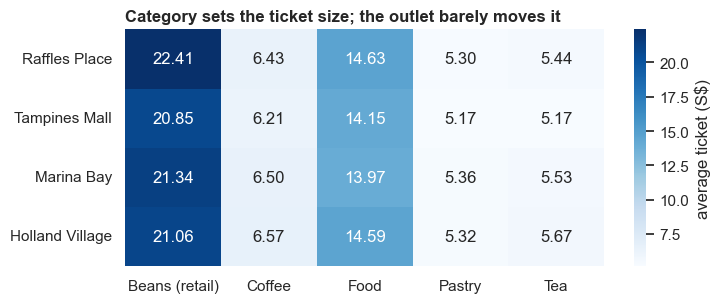

In [51]:
# 👉 Average ticket value, outlet down the side, category across the top.
#    Step 1 -- pivot_table gives exactly the shape a heatmap wants: two categorical axes, one number.
avg_ticket = tickets.pivot_table(
    index="outlet_id", columns="category", values="amount_sgd", aggfunc="mean"
)
avg_ticket.index = [names[i] for i in avg_ticket.index]   # names, not codes

fig, ax = plt.subplots(figsize=(7.5, 3.2))

# 👉 Step 2 -- `annot=True` prints the value in each cell. A heatmap without numbers asks the reader
#    to decode colour, which is the least accurate channel there is.
sns.heatmap(avg_ticket, annot=True, fmt=".2f", cmap="Blues",
            cbar_kws={"label": "average ticket (S$)"}, ax=ax)

ax.set_title("Category sets the ticket size; the outlet barely moves it", loc="left", weight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

# 👉 Read it by ROW and by COLUMN and you get two different findings:
#    - across columns: beans (~$21) and food (~$14) are a different business from coffee/tea/pastry (~$5-7)
#    - down any column: the four outlets agree to within about 30 cents
#    So the variation is in WHAT is sold, not WHERE. That is the same conclusion as the box plot,
#    reached from a different direction -- which is how you know it is real.

---

**⏭ Up next — Part 4: Chart Choice & the One Slide.**

📂 Open `Part_4_chart_choice.ipynb` to continue.